# 対戦データの探索的データ分析

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'Hiragino Sans'

## データの基本情報

In [23]:
# ==========================================
# 1. データの読み込みとカラム（列名）の確認
# ==========================================
TRAIN_CSV = '../data/train_matches.csv'
df = pd.read_csv(TRAIN_CSV)

print(" 【データセットの基本情報】")
print(f"総データ件数: {len(df)} 件")
print("\n 【カラム（列名）一覧】")
print(df.columns.tolist())
print("-" * 40)

# ==========================================
# 2. 勝・負・引き分けの割合（分布）を確認
# ==========================================
# 勝(1), 負(-1 または 0等), 引分(0) の数をカウント
result_counts = df['result'].value_counts().sort_index()

print("\n 【勝敗の分布】")
for res, count in result_counts.items():
    if res > 0: # type: ignore
        label = "勝ち"
    elif res < 0: # type: ignore
        label = "負け"
    else:
        label = "引き分け"
    print(f"  {label} (result={res}): {count}件 ({count/len(df)*100:.1f}%)")


 【データセットの基本情報】
総データ件数: 19871 件

 【カラム（列名）一覧】
['my_0', 'my_1', 'my_2', 'my_3', 'my_4', 'my_5', 'my_6', 'my_7', 'op_0', 'op_1', 'op_2', 'op_3', 'op_4', 'op_5', 'op_6', 'op_7', 'result', 'my_crowns', 'op_crowns', 'my_lev_avg', 'op_lev_avg', 'battle_time']
----------------------------------------

 【勝敗の分布】
  負け (result=-1): 7825件 (39.4%)
  引き分け (result=0): 269件 (1.4%)
  勝ち (result=1): 11777件 (59.3%)


## 勝率の高いカードランキンング(全カード)
3コスト以下や呪文カードなど汎用性の高いカードが勝率で上位に位置した。これは採用率からであると考えられるため、勝敗予測においてはノイズになりうるかも・・


【勝った試合のデッキ採用率ランキング Top 20】
           card_name  win_count
0          Skeletons       5766
1           Fireball       5649
2   Barbarian Barrel       4309
3        Royal Ghost       4126
4       Magic Archer       3409
5            The Log       3155
6     Electro Spirit       3071
7                Zap       2224
8             Cannon       2101
9             Knight       2095
10        Royal Hogs       1515
11       Dark Prince       1500
12           Goblins       1444
13       Fire Spirit       1400
14           Tornado       1360
15         Fisherman       1341
16            Arrows       1311
17       Mega Minion       1242
18        Ice Spirit       1239
19       Royal Giant       1223


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/1655600362.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_cards, x='card_name', y='win_count', palette='viridis')


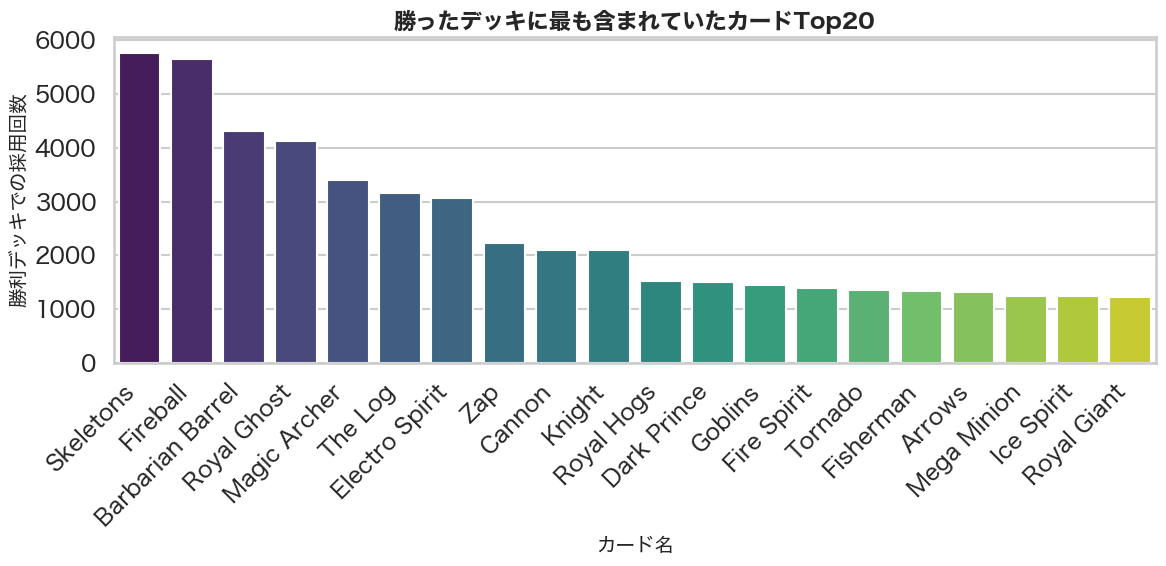

In [24]:
CARDS_JSON = '../data/cards.json'

with open(CARDS_JSON, 'r', encoding='utf-8') as f:
    cards_data = json.load(f)

# JSONの構造に合わせてマッピング辞書を作成します。
# 例1: {"26000000": "Knight"} のような構造なら v のままでOK
# 例2: {"26000000": {"name": "Knight"}} のような構造なら v["name"] に変更してください
id_to_name = {}
for k, v in cards_data.items():
    if isinstance(v, dict):
        # 辞書の中に 'name' というキーがあればそれを使い、なければIDをそのまま使う
        id_to_name[int(k)] = v.get('name', str(k))
    else:
        id_to_name[int(k)] = str(v)

win_df = df[df['result'] > 0]

# my_0 から my_7 までのカードIDをすべて縦一列に並べる
my_cards_cols = [f'my_{i}' for i in range(8)]
winning_cards = win_df[my_cards_cols].values.flatten()

# カウントとDataFrame化
card_counts = pd.Series(winning_cards).value_counts().reset_index()
card_counts.columns = ['card_id', 'win_count']

# カードIDを名前に変換（辞書にない場合はIDの文字列をそのまま使う）
card_counts['card_name'] = card_counts['card_id'].map(id_to_name)
card_counts['card_name'] = card_counts['card_name'].fillna(card_counts['card_id'].astype(str))

top_20_cards = card_counts.head(20)

print("\n【勝った試合のデッキ採用率ランキング Top 20】")
print(top_20_cards[['card_name', 'win_count']])

# グラフ化
plt.figure(figsize=(12, 6))
# x軸を card_name に変更
sns.barplot(data=top_20_cards, x='card_name', y='win_count', palette='viridis')

plt.title('勝ったデッキに最も含まれていたカードTop20', fontsize=16, fontweight='bold')
plt.xlabel('カード名', fontsize=14)
plt.ylabel('勝利デッキでの採用回数', fontsize=14)
# 名前が重ならないようにラベルを斜めに傾ける
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 勝率の高いカードランキンング(3コスト以下と呪文カードを除く)
マジックアーチャーが圧倒的に最強カードとしてゲームを支配していることがわかる。このような環境カード(進化やヒーローの実装)に注意することでより高い精度を叩き出すことができるのでは

【勝った試合のデッキ採用率ランキング Top 20 (4コスト以上・呪文抜き)】
     card_name  win_count
  Magic Archer       3409
    Royal Hogs       1515
   Dark Prince       1500
   Royal Giant       1223
    Goblin Hut       1188
        Hunter       1168
         Tesla       1023
      Valkyrie        961
     Hog Rider        911
Giant Skeleton        882
    Battle Ram        849
  Goblin Drill        788
       Balloon        752
         Giant        738
   Baby Dragon        713
       Rascals        710
Electro Wizard        664
         Golem        652
         X-Bow        643
     Musketeer        631


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/722852435.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_cards, x='card_name', y='win_count', palette='viridis')


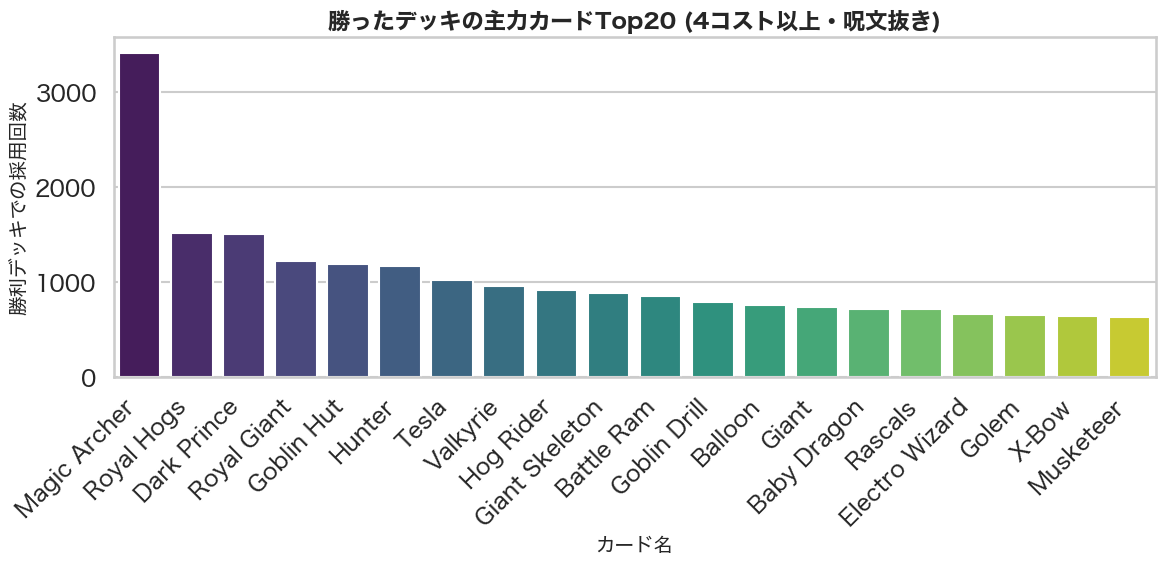

In [25]:
# ==========================================
# 1. データの読み込みとカード情報の抽出
# ==========================================
win_df = df[df['result'] > 0].copy()

with open('../data/cards.json', 'r', encoding='utf-8') as f:
    cards_data = json.load(f)

# カードの名前とコストを辞書に格納（キーを文字列として統一）
id_to_info = {}
for k, v in cards_data.items():
    if isinstance(v, dict):
        name = v.get('name', str(k))
        cost = v.get('elixirCost', 99) # 判明した 'elixirCost' を直接指定
        id_to_info[str(k)] = {'name': name, 'cost': cost} 
    else:
        id_to_info[str(k)] = {'name': str(v), 'cost': 99}

# ==========================================
# 2. ランキングの作成と厳密なフィルタリング
# ==========================================
my_cards_cols = [f'my_{i}' for i in range(8)]
winning_cards = win_df[my_cards_cols].values.flatten()

# CSVのカードID(数値)をすべて文字列に変換してカウント
winning_cards_str = [str(c) for c in winning_cards]

card_counts = pd.Series(winning_cards_str).value_counts().reset_index()
card_counts.columns = ['card_id', 'win_count']

# フィルタリング関数の定義
def is_target_card(card_id):
    # 条件1: 呪文カード（先頭が '28'）を弾く
    if card_id.startswith('28'):
        return False
    
    # 条件2: 3コスト以下のカードを除外
    card_info = id_to_info.get(card_id, {})
    cost = card_info.get('cost', 99)
    if cost <= 3:
        return False
        
    return True

# フィルタリングの適用
filtered_counts = card_counts[card_counts['card_id'].apply(is_target_card)].copy()

# IDから名前に変換
filtered_counts['card_name'] = filtered_counts['card_id'].map(lambda x: id_to_info.get(x, {}).get('name', x))

top_20_cards = filtered_counts.head(20)

print("【勝った試合のデッキ採用率ランキング Top 20 (4コスト以上・呪文抜き)】")
print(top_20_cards[['card_name', 'win_count']].to_string(index=False))

# ==========================================
# 3. グラフ化
# ==========================================
plt.figure(figsize=(12, 6))
sns.barplot(data=top_20_cards, x='card_name', y='win_count', palette='viridis')

plt.title('勝ったデッキの主力カードTop20 (4コスト以上・呪文抜き)', fontsize=16, fontweight='bold')
plt.xlabel('カード名', fontsize=14)
plt.ylabel('勝利デッキでの採用回数', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 基礎統計量の確認

【指定カラムの基礎統計量】


,my_crowns,op_crowns,my_lev_avg,op_lev_avg
count,19871.00,19871.00,19871.00,19871.00
mean,0.87,0.63,25.59,25.53
std,0.85,0.81,1.09,1.13
min,0.00,0.00,22.12,21.88
25%,0.00,0.00,24.88,24.62
50%,1.00,0.00,25.62,25.62
75%,1.00,1.00,26.25,26.25
max,3.00,3.00,28.50,29.00


----------------------------------------


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/3760233836.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='my_crowns', ax=axes[0], palette='Blues_r')
/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/3760233836.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='op_crowns', ax=axes[1], palette='Reds_r')


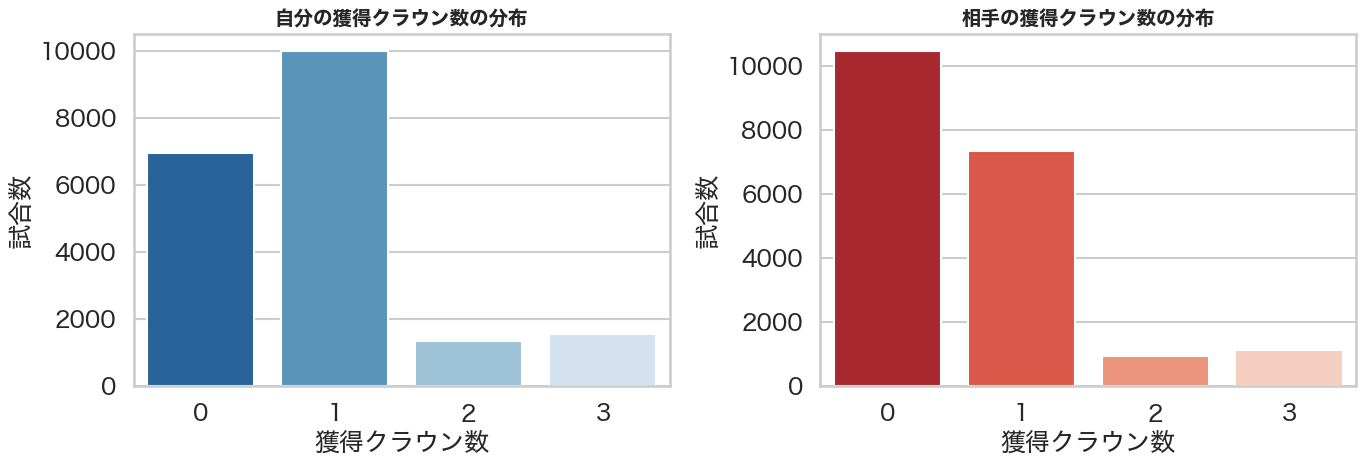

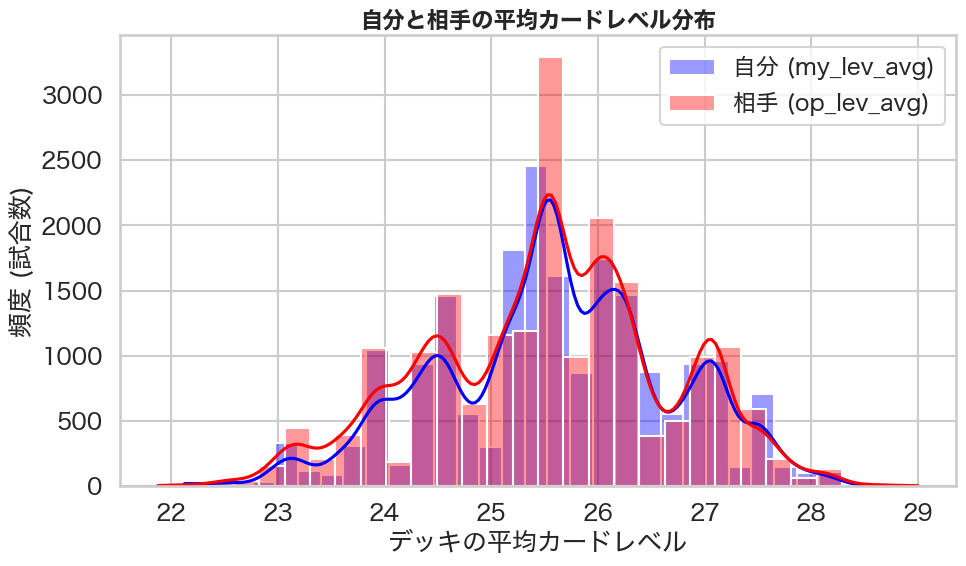

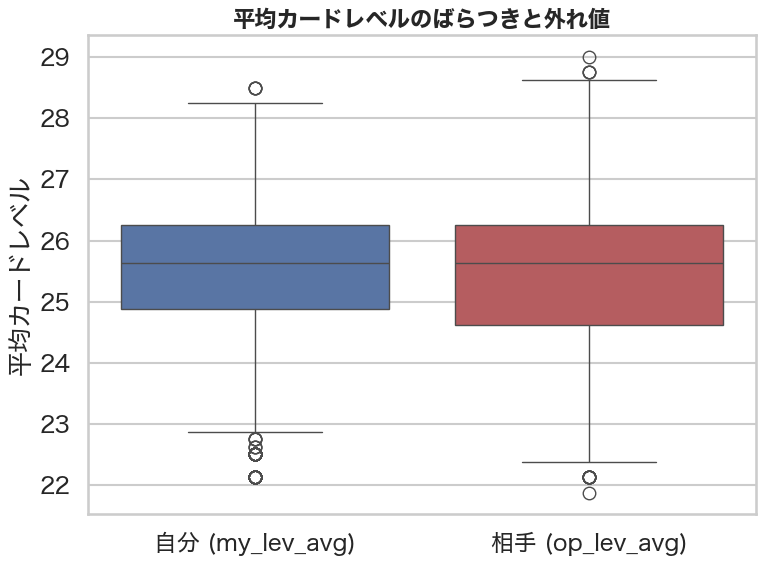

In [26]:
# ==========================================
# 1. 基礎統計量（平均、最大、最小、四分位数など）の確認
# ==========================================
target_cols = ['my_crowns', 'op_crowns', 'my_lev_avg', 'op_lev_avg']

print("【指定カラムの基礎統計量】")
display(df[target_cols].describe().round(2))
print("-" * 40)

# ==========================================
# 2. 獲得クラウン数の分布（カウントプロット）
# ==========================================
# クラウン数は 0, 1, 2, 3 の離散値なので棒グラフで比較します
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='my_crowns', ax=axes[0], palette='Blues_r')
axes[0].set_title('自分の獲得クラウン数の分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('獲得クラウン数')
axes[0].set_ylabel('試合数')

sns.countplot(data=df, x='op_crowns', ax=axes[1], palette='Reds_r')
axes[1].set_title('相手の獲得クラウン数の分布', fontsize=14, fontweight='bold')
axes[1].set_xlabel('獲得クラウン数')
axes[1].set_ylabel('試合数')

plt.tight_layout()
plt.show()

# ==========================================
# 3. 平均カードレベルの分布比較（ヒストグラム）
# ==========================================
# レベルは連続値としてヒストグラムと密度曲線（KDE）で重ねて描画します
plt.figure(figsize=(10, 6))

sns.histplot(df['my_lev_avg'], color='blue', label='自分 (my_lev_avg)', kde=True, alpha=0.4, bins=30) # type: ignore
sns.histplot(df['op_lev_avg'], color='red', label='相手 (op_lev_avg)', kde=True, alpha=0.4, bins=30) # type: ignore

plt.title('自分と相手の平均カードレベル分布', fontsize=16, fontweight='bold')
plt.xlabel('デッキの平均カードレベル')
plt.ylabel('頻度 (試合数)')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 4. レベルの外れ値とばらつきの確認（箱ひげ図）
# ==========================================
plt.figure(figsize=(8, 6))

# 自分と相手のレベルを並べて箱ひげ図を作成
sns.boxplot(data=df[['my_lev_avg', 'op_lev_avg']], palette=['#4C72B0', '#C44E52'])

plt.title('平均カードレベルのばらつきと外れ値', fontsize=16, fontweight='bold')
plt.xticks([0, 1], ['自分 (my_lev_avg)', '相手 (op_lev_avg)'])
plt.ylabel('平均カードレベル')
plt.tight_layout()
plt.show()

## 勝った試合の中でも3クラウン勝利した試合に含まれるカードランキング

3クラウン勝利の試合数: 1566 件 (全体の 7.9%)
----------------------------------------
【3クラウン勝利デッキの主力カードTop 20 (4コスト以上・呪文抜き)】
     card_name  win_count
  Magic Archer        303
   Dark Prince        297
         Golem        227
   Night Witch        220
         Giant        189
Inferno Dragon        156
       Balloon        156
    Lumberjack        151
    Battle Ram        146
Mini P.E.K.K.A        142
Giant Skeleton        127
   Royal Giant        127
        Hunter        124
   Baby Dragon        124
    Lava Hound        118
   Mega Knight        113
    Barbarians        111
        Wizard        109
    Royal Hogs        108
      Valkyrie        107


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/3524174060.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_cards_3crown, x='card_name', y='win_count', palette='magma')


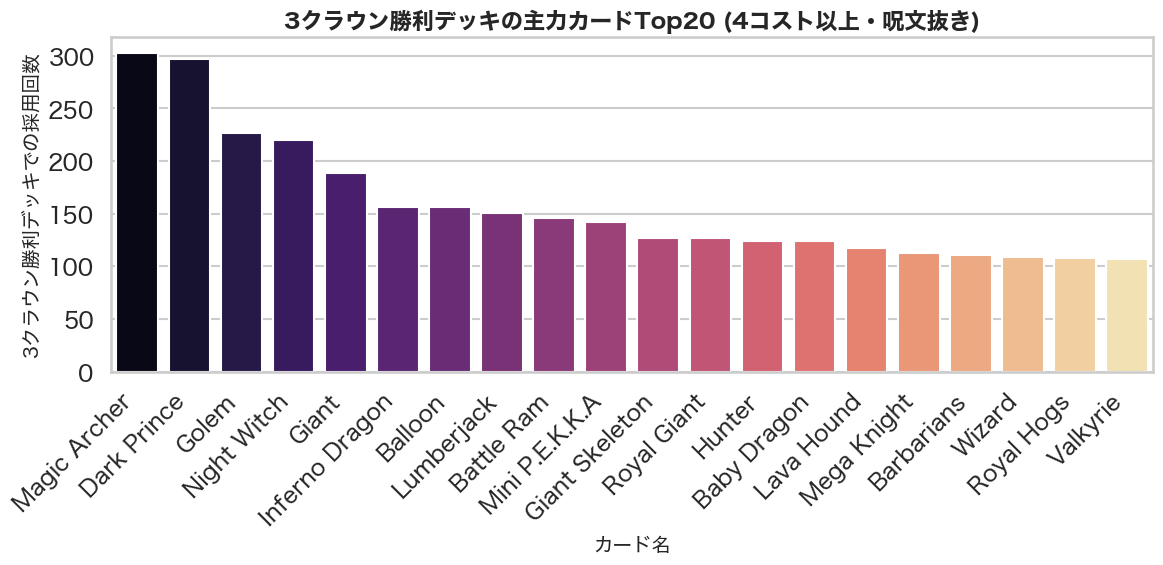

In [27]:
# ==========================================
# 1. データの絞り込み（3クラウン勝利のみ）
# ==========================================
# 勝ち(result > 0) かつ 3クラウン獲得(my_crowns == 3) の試合を抽出
three_crown_win_df = df[(df['result'] > 0) & (df['my_crowns'] == 3)].copy()

print(f"3クラウン勝利の試合数: {len(three_crown_win_df)} 件 (全体の {len(three_crown_win_df)/len(df)*100:.1f}%)")
print("-" * 40)

# ==========================================
# 2. ランキングの作成と厳密なフィルタリング
# ==========================================
my_cards_cols = [f'my_{i}' for i in range(8)]
winning_cards = three_crown_win_df[my_cards_cols].values.flatten()

# CSVのカードID(数値)をすべて文字列に変換してカウント
winning_cards_str = [str(c) for c in winning_cards]

card_counts = pd.Series(winning_cards_str).value_counts().reset_index()
card_counts.columns = ['card_id', 'win_count']

# フィルタリング関数の定義 (前回の id_to_info をそのまま使用)
def is_target_card(card_id):
    # 条件1: 呪文カード（先頭が '28'）を弾く
    if card_id.startswith('28'):
        return False
    
    # 条件2: 3コスト以下のカードを除外
    card_info = id_to_info.get(card_id, {})
    cost = card_info.get('cost', 99)
    if cost <= 3:
        return False
        
    return True

# フィルタリングの適用
filtered_counts = card_counts[card_counts['card_id'].apply(is_target_card)].copy()

# IDから名前に変換
filtered_counts['card_name'] = filtered_counts['card_id'].map(lambda x: id_to_info.get(x, {}).get('name', x))

top_20_cards_3crown = filtered_counts.head(20)

print("【3クラウン勝利デッキの主力カードTop 20 (4コスト以上・呪文抜き)】")
print(top_20_cards_3crown[['card_name', 'win_count']].to_string(index=False))

# ==========================================
# 3. グラフ化
# ==========================================
plt.figure(figsize=(12, 6))
# 3クラウンの特別感を出すために少し違うカラーパレット(magma)を使用
sns.barplot(data=top_20_cards_3crown, x='card_name', y='win_count', palette='magma')

plt.title('3クラウン勝利デッキの主力カードTop20 (4コスト以上・呪文抜き)', fontsize=16, fontweight='bold')
plt.xlabel('カード名', fontsize=14)
plt.ylabel('3クラウン勝利デッキでの採用回数', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 勝率ランキング


【真のカード勝率ランキング Top 20】
            card_name   win_rate  win_count  total_count
113    Flying Machine  69.230769         63           91
112      Goblin Curse  67.000000         67          100
114  Three Musketeers  64.935065         50           77
99     Royal Recruits  64.502165        149          231
90              Witch  64.425770        230          357
102       Goblin Gang  64.390244        132          205
86             Sparky  63.657957        268          421
96            Phoenix  63.432836        170          268
115     Spear Goblins  63.157895         48           76
95          Berserker  62.730627        170          271
70        Executioner  62.034384        433          698
60             Wizard  61.748014        544          881
77       Mother Witch  61.674718        383          621
78            Zappies  61.359867        370          603
104    Electro Dragon  61.271676        106          173
91        Heal Spirit  61.189802        216          353
10      

/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/961803401.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_cards, x='card_name', y='win_rate', palette='magma')


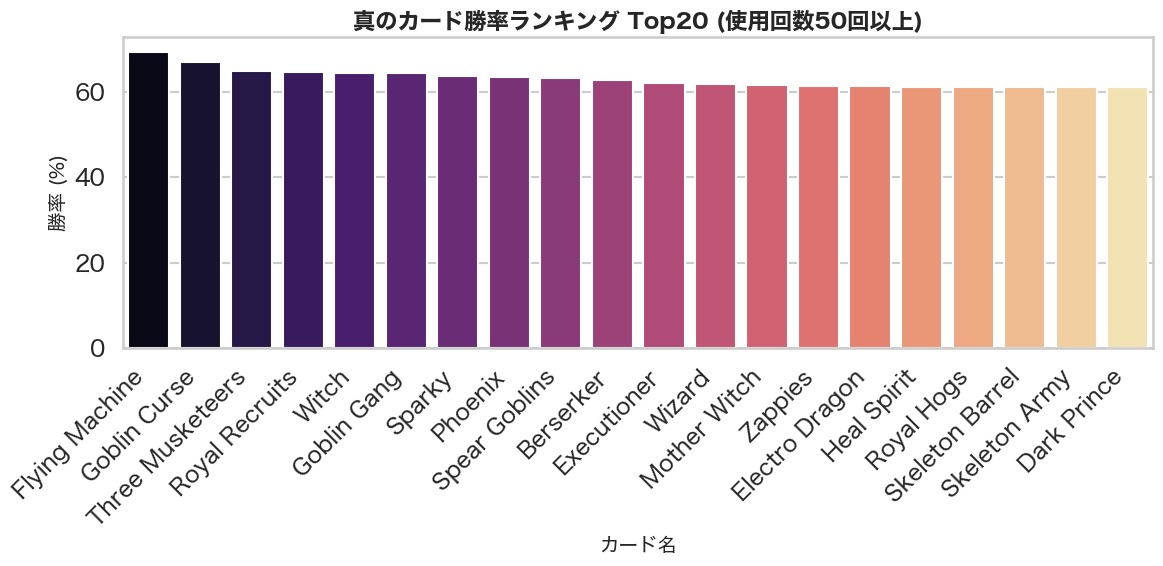

In [64]:
id_to_name = {}
for k, v in cards_data.items():
    if isinstance(v, dict):
        id_to_name[int(k)] = v.get('name', str(k))
    else:
        id_to_name[int(k)] = str(v)

# my_0 から my_7 までのカラム名
my_cards_cols = [f'my_{i}' for i in range(8)]

# --- 1. 全試合での採用回数（Total Count）を計算 ---
all_cards = df[my_cards_cols].values.flatten()
total_counts = pd.Series(all_cards).value_counts().reset_index()
total_counts.columns = ['card_id', 'total_count']

# --- 2. 勝った試合での採用回数（Win Count）を計算 ---
win_df = df[df['result'] > 0]
winning_cards = win_df[my_cards_cols].values.flatten()
win_counts = pd.Series(winning_cards).value_counts().reset_index()
win_counts.columns = ['card_id', 'win_count']

# --- 3. 2つのデータを結合して勝率（Win Rate）を計算 ---
card_stats = pd.merge(total_counts, win_counts, on='card_id', how='left').fillna(0)
card_stats['win_rate'] = (card_stats['win_count'] / card_stats['total_count']) * 100

# 🌟 重要なポイント: 採用回数が少なすぎるカード（ノイズ）を除外する
# 例：1回だけ使われて1回勝った「勝率100%」のカードを弾くため、全体で50回以上使われたものに絞る
MIN_USES = 50 
card_stats = card_stats[card_stats['total_count'] >= MIN_USES]

# 勝率が高い順に並び替え
card_stats = card_stats.sort_values(by='win_rate', ascending=False)

# --- 4. 名前をマッピング ---
card_stats['card_name'] = card_stats['card_id'].map(id_to_name)
card_stats['card_name'] = card_stats['card_name'].fillna(card_stats['card_id'].astype(str))

top_20_cards = card_stats.head(20)

print("\n【真のカード勝率ランキング Top 20】")
print(top_20_cards[['card_name', 'win_rate', 'win_count', 'total_count']])

# --- 5. グラフ化 ---
plt.figure(figsize=(12, 6))
sns.barplot(data=top_20_cards, x='card_name', y='win_rate', palette='magma')

plt.title('真のカード勝率ランキング Top20 (使用回数50回以上)', fontsize=16, fontweight='bold')
plt.xlabel('カード名', fontsize=14)
plt.ylabel('勝率 (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')

# 縦軸を少し見やすく調整（例: 40%〜60%の範囲にズーム）
# plt.ylim(40, 65) 

plt.tight_layout()
plt.show()

## 勝率に関する相関分析
1. デッキ平均コスト差と勝率の関係
2. カードの使用率 vs 勝率（散布図）
- 左上（使用率は低いが、勝率が異常に高い「隠れ最強カード」）
- 右上（みんなが使っていて、かつ勝率も高い「環境トップカード」）

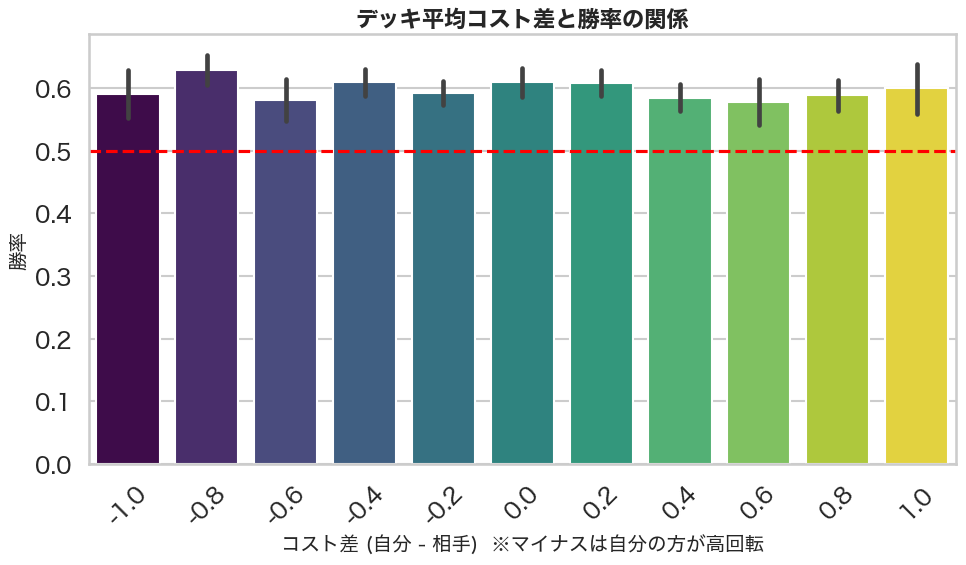

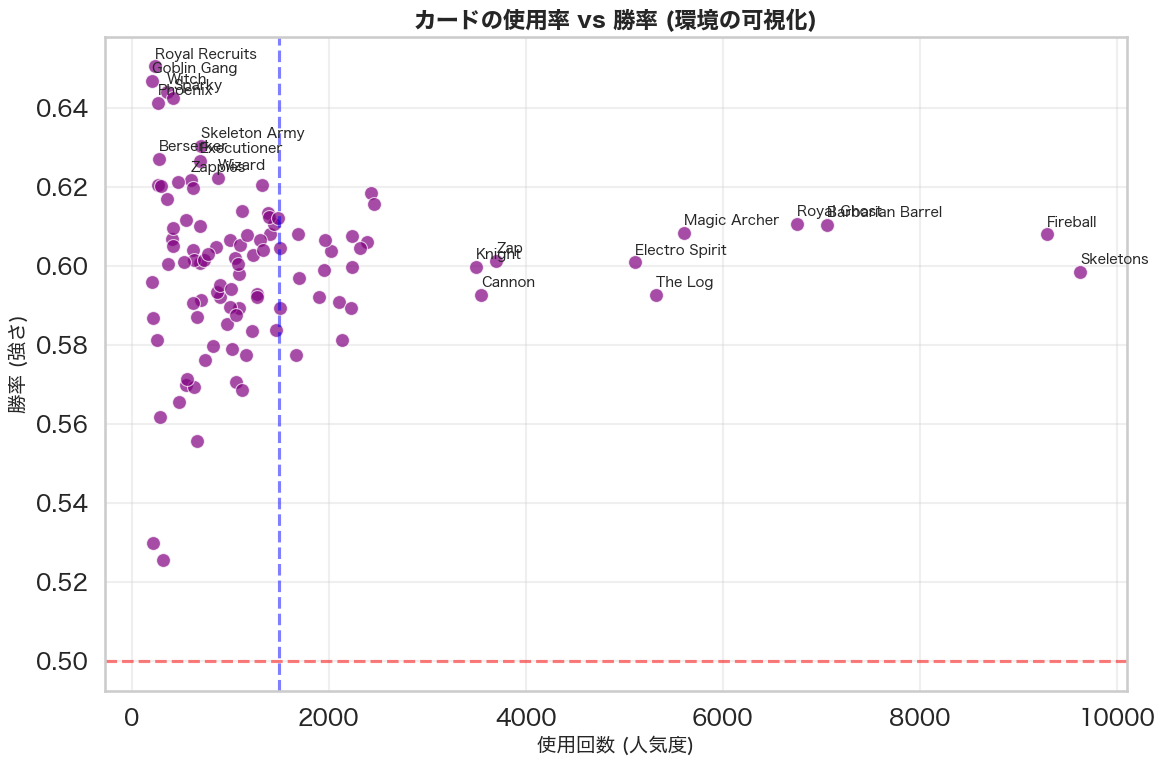

In [31]:
# ==========================================
# 準備0: 分析用データフレーム(eda_df)の作成
# ==========================================
# 引き分け(0)を除外したデータを作成し、勝敗を0と1に変換
eda_df = df[df['result'] != 0].copy()
eda_df['is_win'] = (eda_df['result'] == 1).astype(int)

# ==========================================
# 準備1: デッキの平均エリクサーコストを計算する
# ==========================================
def calculate_avg_elixir(row, prefix):
    total_cost = 0
    valid_cards = 0
    for i in range(8):
        raw_val = row[f'{prefix}_{i}']
        card_id = str(int(float(raw_val))) 
        
        cost = id_to_info.get(card_id, {}).get('cost', 99)
        if cost != 99:
            total_cost += cost
            valid_cards += 1
    return total_cost / valid_cards if valid_cards > 0 else 0

# 各試合の自分と相手の平均コストを計算（処理に数秒かかります）
eda_df['my_elixir_avg'] = eda_df.apply(lambda r: calculate_avg_elixir(r, 'my'), axis=1)
eda_df['op_elixir_avg'] = eda_df.apply(lambda r: calculate_avg_elixir(r, 'op'), axis=1)

# コスト差（自分の平均コスト - 相手の平均コスト）
eda_df['elixir_diff'] = eda_df['my_elixir_avg'] - eda_df['op_elixir_avg']


# ==========================================
# グラフ①：デッキコスト差と勝率の関係
# ==========================================
plt.figure(figsize=(10, 6))

eda_df['elixir_diff_bin'] = (eda_df['elixir_diff'] * 5).round() / 5
plot_df = eda_df[(eda_df['elixir_diff_bin'] >= -1.0) & (eda_df['elixir_diff_bin'] <= 1.0)]

sns.barplot(data=plot_df, x='elixir_diff_bin', y='is_win', hue='elixir_diff_bin', palette='viridis', legend=False)
plt.axhline(0.5, color='red', linestyle='--')
plt.title('デッキ平均コスト差と勝率の関係', fontsize=16, fontweight='bold')
plt.xlabel('コスト差 (自分 - 相手)  ※マイナスは自分の方が高回転', fontsize=14)
plt.ylabel('勝率', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================
# グラフ②：カードの使用率 vs 勝率（散布図）
# ==========================================
my_cards_cols = [f'my_{i}' for i in range(8)]

all_my_cards = [str(int(float(c))) for c in eda_df[my_cards_cols].values.flatten()]
win_my_cards = [str(int(float(c))) for c in eda_df[eda_df['is_win'] == 1][my_cards_cols].values.flatten()]

total_counts = pd.Series(all_my_cards).value_counts()
win_counts = pd.Series(win_my_cards).value_counts()

card_stats = pd.DataFrame({'total_uses': total_counts, 'wins': win_counts}).fillna(0)
card_stats['win_rate'] = card_stats['wins'] / card_stats['total_uses']

min_use_threshold = len(eda_df) * 0.01
card_stats = card_stats[card_stats['total_uses'] >= min_use_threshold].copy()
card_stats['card_name'] = card_stats.index.map(lambda x: id_to_info.get(x, {}).get('name', x))

plt.figure(figsize=(12, 8))
sns.scatterplot(data=card_stats, x='total_uses', y='win_rate', s=100, alpha=0.7, color='purple')

plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(card_stats['total_uses'].mean(), color='blue', linestyle='--', alpha=0.5)

top_winrate = card_stats.nlargest(10, 'win_rate')
top_usage = card_stats.nlargest(10, 'total_uses')
highlight_cards = pd.concat([top_winrate, top_usage]).drop_duplicates()

for _, row in highlight_cards.iterrows():
    plt.text(row['total_uses'], row['win_rate'] + 0.002, row['card_name'], fontsize=10)

plt.title('カードの使用率 vs 勝率 (環境の可視化)', fontsize=16, fontweight='bold')
plt.xlabel('使用回数 (人気度)', fontsize=14)
plt.ylabel('勝率 (強さ)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 勝率が高いカード同士の共起回数ヒートマップ

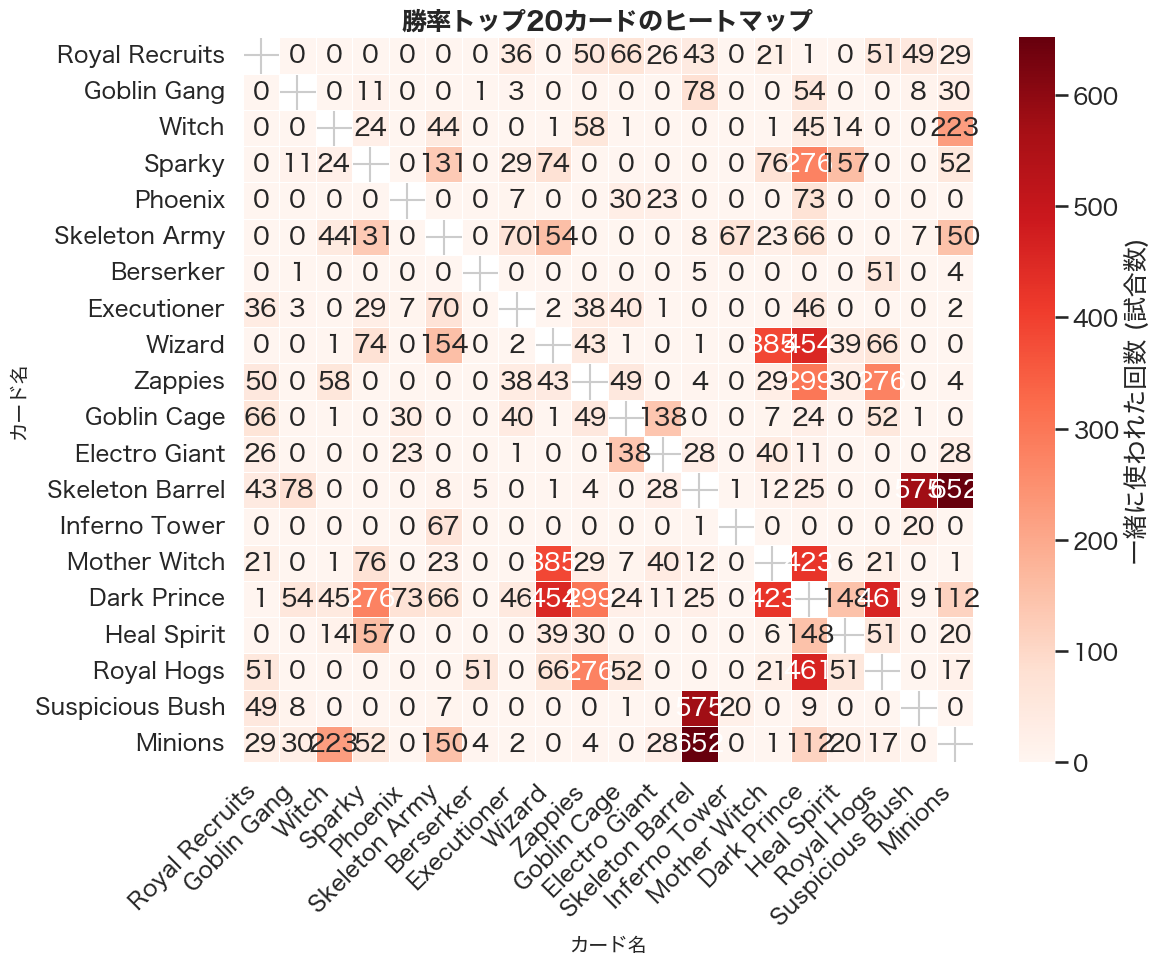

In [33]:
import itertools

# ==========================================
# 1. 勝率上位のカード（トップ15）を抽出
# ==========================================
# 前回作成した card_stats（使用率1%以上のカード統計）から勝率上位15枚を取得
top_15_cards = card_stats.nlargest(20, 'win_rate').copy()
top_card_ids = top_15_cards.index.tolist()
top_card_names = top_15_cards['card_name'].tolist()

# ==========================================
# 2. 共起行列（一緒に使われた回数を数える箱）の作成
# ==========================================
# 縦横にトップ15のカード名を並べたゼロ埋めの表を作る
co_matrix = pd.DataFrame(0, index=top_card_names, columns=top_card_names)

my_cards_cols = [f'my_{i}' for i in range(8)]

# 各試合のデッキをループして、トップ15カードが同時に採用されているかチェック
for _, row in eda_df.iterrows():
    deck_cards = [str(int(float(row[c]))) for c in my_cards_cols]
    
    # そのデッキの中に、トップ15のカードが何枚含まれているか抽出
    cards_in_top15 = [c for c in deck_cards if c in top_card_ids]
    
    # 2枚以上含まれていれば、それぞれの組み合わせ（ペア）のカウントを+1する
    if len(cards_in_top15) >= 2:
        names_in_deck = [id_to_info.get(c, {}).get('name', c) for c in cards_in_top15]
        for c1, c2 in itertools.combinations(names_in_deck, 2):
            co_matrix.at[c1, c2] += 1
            co_matrix.at[c2, c1] += 1

# ==========================================
# 3. ヒートマップの描画
# ==========================================
plt.figure(figsize=(12, 10))

# 対角成分（自分自身との組み合わせ）は意味がないので非表示(マスク)にする
mask = np.zeros_like(co_matrix, dtype=bool)
np.fill_diagonal(mask, True)

# ヒートマップ描画 (色が濃いほど一緒によく使われている)
sns.heatmap(co_matrix, mask=mask, annot=True, fmt="d", cmap="Reds", 
            linewidths=.5, cbar_kws={'label': '一緒に使われた回数 (試合数)'})

plt.title('勝率トップ20カードのヒートマップ', fontsize=18, fontweight='bold')
plt.xlabel('カード名', fontsize=14)
plt.ylabel('カード名', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 勝率と環境支配カードを含んでいるデッキの相関 (デッキ平均コスト、レベル差も)

/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/1891810278.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='meta_score_diff_percent', y='is_win', palette='coolwarm', legend=False)


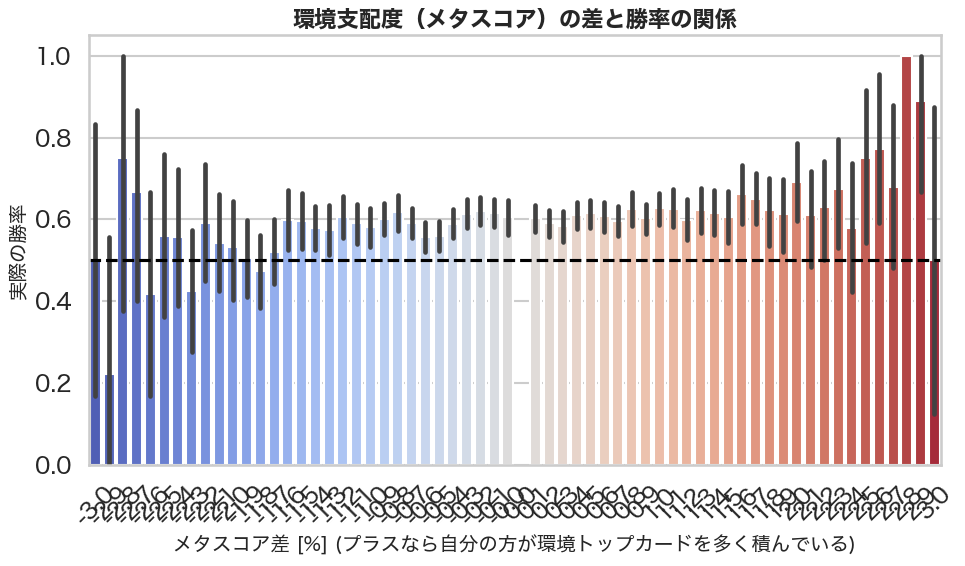

【重要特徴量の相関（Targetとの関係）】


,is_win
is_win,1.000
level_diff,0.004
elixir_diff,-0.015
meta_score_diff,0.039


In [36]:
# ==========================================
# 1. 各カードの「環境支配度（勝率）」を計算
# ==========================================
# 前回の card_stats（使用回数と勝率のデータ）を使用します
# ノイズ（まぐれ勝ち）を防ぐため、一定数以上使われたカードの勝率を辞書化
valid_cards = card_stats[card_stats['total_uses'] >= len(eda_df) * 0.005]
card_winrate_dict = valid_cards['win_rate'].to_dict()

# 平均的な勝率（データがない場合の初期値）
mean_winrate = valid_cards['win_rate'].mean()

# ==========================================
# 2. デッキ全体の「メタスコア（強カードの詰め込み具合）」を計算
# ==========================================
def calculate_deck_meta_score(row, prefix):
    score = 0
    for i in range(8):
        card_id = str(int(float(row[f'{prefix}_{i}'])))
        # 辞書からそのカードの勝率（環境支配度）を取得。なければ平均値。
        score += card_winrate_dict.get(card_id, mean_winrate)
    # 8枚の平均勝率（これがデッキのメタスコア）
    return score / 8.0

# 自分のデッキと相手のデッキのメタスコアを計算（数秒かかります）
eda_df['my_meta_score'] = eda_df.apply(lambda r: calculate_deck_meta_score(r, 'my'), axis=1)
eda_df['op_meta_score'] = eda_df.apply(lambda r: calculate_deck_meta_score(r, 'op'), axis=1)

# 環境支配度の差（自分 - 相手）
eda_df['meta_score_diff'] = eda_df['my_meta_score'] - eda_df['op_meta_score']

# ==========================================
# 3. グラフ：メタスコア差と勝率の関係
# ==========================================
plt.figure(figsize=(10, 6))

# スコア差をパーセント表記（100倍）にして丸める（例: +1.0%, -0.5% など）
eda_df['meta_score_diff_percent'] = (eda_df['meta_score_diff'] * 100).round(1)

# 極端な外れ値を除いて描画
plot_df = eda_df[(eda_df['meta_score_diff_percent'] >= -3.0) & (eda_df['meta_score_diff_percent'] <= 3.0)]

sns.barplot(data=plot_df, x='meta_score_diff_percent', y='is_win', palette='coolwarm', legend=False)
plt.axhline(0.5, color='black', linestyle='--')

plt.title('環境支配度（メタスコア）の差と勝率の関係', fontsize=16, fontweight='bold')
plt.xlabel('メタスコア差 [%] (プラスなら自分の方が環境トップカードを多く積んでいる)', fontsize=14)
plt.ylabel('実際の勝率', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 4. LightGBMへ追加する際の特徴量の相関を確認（修正版）
# ==========================================
# 抜けていた「レベル差」の計算をここで補完
if 'level_diff' not in eda_df.columns:
    eda_df['level_diff'] = eda_df['my_lev_avg'] - eda_df['op_lev_avg']

# 安全のため、確実に存在するカラムだけを抽出して相関を計算
target_cols = ['is_win', 'level_diff', 'elixir_diff', 'meta_score_diff']
available_cols = [c for c in target_cols if c in eda_df.columns]

print("【重要特徴量の相関（Targetとの関係）】")
corr_matrix = eda_df[available_cols].corr()
display(corr_matrix[['is_win']].round(3))

# 推論結果データのEDA

## データの読み込み
MultHot + MLPのベースラインモデルとクロスアテンションモデルの２つの推論結果の分析を行います。

In [55]:
import pandas as pd
import json
import ast
import numpy as np

# --- 1. カード情報の辞書を準備 ---
with open('../data/cards.json', 'r', encoding='utf-8') as f:
    cards_data = json.load(f)

id_to_name = {str(k): v.get('name', str(k)) if isinstance(v, dict) else str(v) for k, v in cards_data.items()}
sorted_card_ids = sorted([int(k) for k in cards_data.keys()])
idx_to_name = {i: id_to_name[str(cid)] for i, cid in enumerate(sorted_card_ids)}

def parse_raw_id_deck(deck_str):
    try:
        deck_ids = ast.literal_eval(deck_str)
        return [idx_to_name.get(c, f"Unknown_{c}") for c in deck_ids]
    except:
        return []

def parse_multihot_deck(deck_str):
    try:
        deck_array = ast.literal_eval(deck_str)
        return [idx_to_name.get(i, f"Unknown_{i}") for i, val in enumerate(deck_array) if val == 1.0]
    except:
        return []

# --- 2. CSVデータの読み込み ---
df_base = pd.read_csv('../data/base_result.csv')
df_attn = pd.read_csv('../data/attention_result.csv')

# それぞれの名前リストに変換
df_base['Deck_A_Names'] = df_base['Deck_A_Predicting'].apply(parse_multihot_deck)
df_base['Deck_B_Names'] = df_base['Deck_B_Opponent'].apply(parse_multihot_deck)

df_attn['Deck_A_Names'] = df_attn['Deck_A_Predicting'].apply(parse_raw_id_deck)
df_attn['Deck_B_Names'] = df_attn['Deck_B_Opponent'].apply(parse_raw_id_deck)

# --- 3. ソート順の乱れを直すための「試合ユニークキー」を作成 ---
def make_match_key(row):
    # デッキの中身をソートして文字列化（順不同でも一致させるため）
    deck_a_str = ','.join(sorted(row['Deck_A_Names']))
    deck_b_str = ','.join(sorted(row['Deck_B_Names']))
    return f"{deck_a_str}_VS_{deck_b_str}_{row['Actual_Result']}"

df_base['Match_Key'] = df_base.apply(make_match_key, axis=1)
df_attn['Match_Key'] = df_attn.apply(make_match_key, axis=1)

# まったく同じデッキ対決が複数あった場合のための連番付与
df_base['Key_Count'] = df_base.groupby('Match_Key').cumcount()
df_attn['Key_Count'] = df_attn.groupby('Match_Key').cumcount()
df_base['Unique_Key'] = df_base['Match_Key'] + "_" + df_base['Key_Count'].astype(str)
df_attn['Unique_Key'] = df_attn['Match_Key'] + "_" + df_attn['Key_Count'].astype(str)

# --- 4. ユニークキーを使って正しくマージ（結合） ---
df_compare = pd.merge(
    df_base[['Unique_Key', 'Actual_Result', 'Deck_A_Names', 'Deck_B_Names', 'Predicted_Label', 'Win_Probability', 'Is_Correct']],
    df_attn[['Unique_Key', 'Predicted_Label', 'Win_Probability', 'Is_Correct']],
    on='Unique_Key',
    suffixes=('_Base', '_Attn')
)

# 使いやすいようにカラム名を変更
df_compare = df_compare.rename(columns={
    'Deck_A_Names': 'Deck_A_Base',
    'Deck_B_Names': 'Deck_B_Base',
    'Predicted_Label_Base': 'Pred_Base',
    'Win_Probability_Base': 'Prob_Base',
    'Is_Correct_Base': 'Correct_Base',
    'Predicted_Label_Attn': 'Pred_Attn',
    'Win_Probability_Attn': 'Prob_Attn',
    'Is_Correct_Attn': 'Correct_Attn'
})

print(f" デッキ情報に基づく正しいデータ結合が完了しました！ (全 {len(df_compare)} 試合)")

 デッキ情報に基づく正しいデータ結合が完了しました！ (全 4416 試合)


In [60]:
# --- 両モデルの正解・不正解のマトリックス ---
crosstab = pd.crosstab(
    df_compare['Correct_Base'], 
    df_compare['Correct_Attn'], 
    rownames=['Base Model'], 
    colnames=['Attention Model'],
    margins=True
)

print(" 【モデル間の正解比較マトリックス】")
display(crosstab)

both_correct = crosstab.loc[True, True]
both_wrong = crosstab.loc[False, False]
base_only = crosstab.loc[True, False]
attn_only = crosstab.loc[False, True]
total = len(df_compare)

print(f"\n 両方正解: {both_correct}試合 ({both_correct/total*100:.1f}%)") # type: ignore
print(f" Baseのみ正解: {base_only}試合 ({base_only/total*100:.1f}%)") # type: ignore
print(f" Attnのみ正解: {attn_only}試合 ({attn_only/total*100:.1f}%)") # type: ignore
print(f" 両方不正解: {both_wrong}試合 ({both_wrong/total*100:.1f}%)") # type: ignore

 【モデル間の正解比較マトリックス】


Attention Model,False,True,All
Base Model,,,
False,1124,458,1582
True,515,2319,2834
All,1639,2777,4416



 両方正解: 2319試合 (52.5%)
 Baseのみ正解: 515試合 (11.7%)
 Attnのみ正解: 458試合 (10.4%)
 両方不正解: 1124試合 (25.5%)


## クロスアテンションモデルが間違えた対戦

In [58]:
# --- Baseのみ正解し、Attentionが外した試合 ---
df_base_win_attn_lose = df_compare[(df_compare['Correct_Base'] == True) & (df_compare['Correct_Attn'] == False)].copy()

# Baseモデルが「自信満々で当てた」順にソート（確信度：0.5からどれだけ離れているか）
df_base_win_attn_lose['Base_Confidence'] = abs(df_base_win_attn_lose['Prob_Base'] - 0.5)
df_base_win_attn_lose = df_base_win_attn_lose.sort_values(by='Base_Confidence', ascending=False)

print(f" Baseは正解したが、Attentionが間違えた試合: {len(df_base_win_attn_lose)}件")
print("上位5件を表示：\n")

for i, (_, row) in enumerate(df_base_win_attn_lose.head(5).iterrows()):
    print(f"[{i+1}] 実際の勝敗: {'Win' if row['Actual_Result']==1 else 'Lose'}")
    print(f" Base予測: {'Win' if row['Pred_Base']==1 else 'Lose'} (確率: {row['Prob_Base']:.3f}) ⭕️")
    print(f" Attn予測: {'Win' if row['Pred_Attn']==1 else 'Lose'} (確率: {row['Prob_Attn']:.3f}) ❌")
    print(f" 自分デッキ: {', '.join(row['Deck_A_Base'][:8])}") 
    print(f" 相手デッキ: {', '.join(row['Deck_B_Base'][:8])}")
    print("-" * 50)

 Baseは正解したが、Attentionが間違えた試合: 515件
上位5件を表示：

[1] 実際の勝敗: Lose
 Base予測: Lose (確率: 0.012) ⭕️
 Attn予測: Win (確率: 0.700) ❌
 自分デッキ: Archers, Giant, Minions, Barbarians, Bowler, Night Witch, Arrows, Graveyard
 相手デッキ: Giant, Skeleton Army, Mini P.E.K.K.A, Dark Prince, Sparky, Mother Witch, Zap, Vines
--------------------------------------------------
[2] 実際の勝敗: Win
 Base予測: Win (確率: 0.980) ⭕️
 Attn予測: Lose (確率: 0.075) ❌
 自分デッキ: Valkyrie, Hog Rider, Guards, Firecracker, Electro Spirit, Tesla, Lightning, The Log
 相手デッキ: Golem, Valkyrie, Baby Dragon, Mini P.E.K.K.A, Zappies, Battle Healer, Elixir Collector, Vines
--------------------------------------------------
[3] 実際の勝敗: Lose
 Base予測: Lose (確率: 0.025) ⭕️
 Attn予測: Win (確率: 0.935) ❌
 自分デッキ: Golem, Valkyrie, Baby Dragon, Mini P.E.K.K.A, Zappies, Battle Healer, Elixir Collector, Vines
 相手デッキ: Valkyrie, Hog Rider, Guards, Firecracker, Electro Spirit, Tesla, Lightning, The Log
--------------------------------------------------
[4] 実際の勝敗: Win
 Base予測:

## ベースモデルが間違えた対戦

In [59]:
# --- Attentionのみ正解し、Baseが外した試合 ---
df_attn_win_base_lose = df_compare[(df_compare['Correct_Attn'] == True) & (df_compare['Correct_Base'] == False)].copy()

# Attentionモデルが「自信満々で当てた」順にソート
df_attn_win_base_lose['Attn_Confidence'] = abs(df_attn_win_base_lose['Prob_Attn'] - 0.5)
df_attn_win_base_lose = df_attn_win_base_lose.sort_values(by='Attn_Confidence', ascending=False)

print(f" Attentionだけが正解できた（相性の機微を見抜いた）試合: {len(df_attn_win_base_lose)}件")
print("上位5件を表示します（特定のカウンターカードが刺さった試合かもしれません）：\n")

for i, (_, row) in enumerate(df_attn_win_base_lose.head(5).iterrows()):
    print(f"[{i+1}] 実際の勝敗: {'Win' if row['Actual_Result']==1 else 'Lose'}")
    print(f" Attn予測: {'Win' if row['Pred_Attn']==1 else 'Lose'} (確率: {row['Prob_Attn']:.3f}) ⭕️")
    print(f" Base予測: {'Win' if row['Pred_Base']==1 else 'Lose'} (確率: {row['Prob_Base']:.3f}) ❌")
    
    # せっかくなのでデッキがよくわかるように8枚すべて表示します
    print(f" 自分デッキ: {', '.join(row['Deck_A_Base'][:8])}") 
    print(f" 相手デッキ: {', '.join(row['Deck_B_Base'][:8])}")
    print("-" * 50)

✨ Attentionだけが正解できた（相性の機微を見抜いた）試合: 458件
上位5件を表示します（特定のカウンターカードが刺さった試合かもしれません）：

[1] 実際の勝敗: Lose
  🧠 Attn予測: Lose (確率: 0.001) ⭕️
  🤖 Base予測: Win (確率: 0.514) ❌
  ⚔️ 自分デッキ: Goblins, Minions, Three Musketeers, Royal Ghost, Royal Hogs, Fireball, Barbarian Barrel, Heal Spirit
  🛡️ 相手デッキ: Skeletons, Mighty Miner, Goblin Demolisher, Cannon, Goblin Drill, Rocket, Giant Snowball, Royal Delivery
--------------------------------------------------
[2] 実際の勝敗: Win
  🧠 Attn予測: Win (確率: 0.999) ⭕️
  🤖 Base予測: Lose (確率: 0.127) ❌
  ⚔️ 自分デッキ: Knight, Baby Dragon, Bowler, Electro Giant, Goblin Cage, Lightning, Tornado, Barbarian Barrel
  🛡️ 相手デッキ: Goblins, Balloon, Wizard, Giant Skeleton, Miner, Bats, Fisherman, Giant Snowball
--------------------------------------------------
[3] 実際の勝敗: Lose
  🧠 Attn予測: Lose (確率: 0.001) ⭕️
  🤖 Base予測: Win (確率: 0.531) ❌
  ⚔️ 自分デッキ: Royal Giant, Guards, Hunter, Fisherman, Monk, Electro Spirit, Rage, The Log
  🛡️ 相手デッキ: Knight, Balloon, Miner, Bats, Mega Knight, Arrows, Zap, 

## 間違えた対戦に入っているカードランキング

In [62]:
import pandas as pd

# --- 1. テストデータ全体での各カードの登場回数をカウント ---
# 両方のデッキを展開して合算
all_cards_a = df_compare['Deck_A_Base'].explode()
all_cards_b = df_compare['Deck_B_Base'].explode()
total_card_counts = pd.concat([all_cards_a, all_cards_b]).value_counts()

def get_error_ranking(condition, title, min_appearances=30):
    """ 指定した条件（間違えた試合）に絞って、カードごとのエラー率を計算する関数 """
    df_errors = df_compare[condition]
    
    # エラーになった試合のカードをカウント
    err_cards_a = df_errors['Deck_A_Base'].explode()
    err_cards_b = df_errors['Deck_B_Base'].explode()
    error_counts = pd.concat([err_cards_a, err_cards_b]).value_counts()
    
    # 全体回数と結合してエラー率を計算
    df_stats = pd.DataFrame({
        'Error_Count': error_counts, 
        'Total_Count': total_card_counts
    }).fillna(0)
    
    df_stats['Error_Rate (%)'] = (df_stats['Error_Count'] / df_stats['Total_Count']) * 100
    
    # 登場回数が少なすぎるカード（ノイズ）を除外して、エラー率が高い順にソート
    df_stats = df_stats[df_stats['Total_Count'] >= min_appearances]
    df_stats = df_stats.sort_values(by='Error_Rate (%)', ascending=False)
    
    print("\n" + "="*50)
    print(f" {title}")
    print("="*50)
    display(df_stats[['Error_Rate (%)', 'Error_Count', 'Total_Count']].head(10).round(1))

# --- 2. 3パターンのランキングを出力 ---

# ① 両方のモデルが間違えた（根本的に予測が難しい）カード
cond_both_wrong = (df_compare['Correct_Base'] == False) & (df_compare['Correct_Attn'] == False)
get_error_ranking(cond_both_wrong, "【両方間違えた】AIにとって最も予測が難しいカード Top10")

# ② Baseは正解したが、Attentionが間違えた（深読みして自滅する原因の）カード
cond_attn_only_wrong = (df_compare['Correct_Base'] == True) & (df_compare['Correct_Attn'] == False)
get_error_ranking(cond_attn_only_wrong, "【Attentionだけ間違えた】Attention機構を狂わせるカード Top10")

# ③ Attentionは正解したが、Baseが間違えた（相性の影響が強すぎる）カード
cond_base_only_wrong = (df_compare['Correct_Base'] == False) & (df_compare['Correct_Attn'] == True)
get_error_ranking(cond_base_only_wrong, "【Baseだけ間違えた】複雑な相性・シナジーを持つカード Top10")


 【両方間違えた】AIにとって最も予測が難しいカード Top10


,Error_Rate (%),Error_Count,Total_Count
Three Musketeers,40.6,13.0,32
Battle Healer,32.4,22.0,68
Earthquake,31.9,81.0,254
Hunter,31.5,269.0,854
Royal Giant,30.9,285.0,922
Mirror,30.4,14.0,46
Fisherman,30.4,300.0,986
Royal Delivery,29.9,79.0,264
Goblin Barrel,29.7,73.0,246
Phoenix,28.7,43.0,150



 【Attentionだけ間違えた】Attention機構を狂わせるカード Top10


,Error_Rate (%),Error_Count,Total_Count
Mirror,28.3,13.0,46
Electro Giant,23.5,31.0,132
Battle Healer,20.6,14.0,68
Three Musketeers,18.8,6.0,32
Inferno Tower,17.5,22.0,126
Golden Knight,16.8,43.0,256
Goblin Cage,16.5,42.0,254
Elixir Collector,16.0,24.0,150
Spear Goblins,15.6,5.0,32
Berserker,15.6,15.0,96



 【Baseだけ間違えた】複雑な相性・シナジーを持つカード Top10


,Error_Rate (%),Error_Count,Total_Count
Skeleton Dragons,27.1,13,48
Royal Recruits,20.4,20,98
Rune Giant,19.4,7,36
Three Musketeers,18.8,6,32
Berserker,18.8,18,96
Monk,16.9,26,154
Goblin Curse,15.8,12,76
Goblin Gang,15.0,18,120
Night Witch,14.3,76,530
Elite Barbarians,14.2,25,176


/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/2366612218.py:67: UserWarning: Glyph 12459 (\N{KATAKANA LETTER KA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/2366612218.py:67: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/2366612218.py:67: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/2366612218.py:67: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipykernel_44732/2366612218.py:67: UserWarning: Glyph 21213 (\N{CJK UNIFIED IDEOGRAPH-52DD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/dh/5qgvv3mn3tlgcq_rb9k6l7xm0000gn/T/ipyke

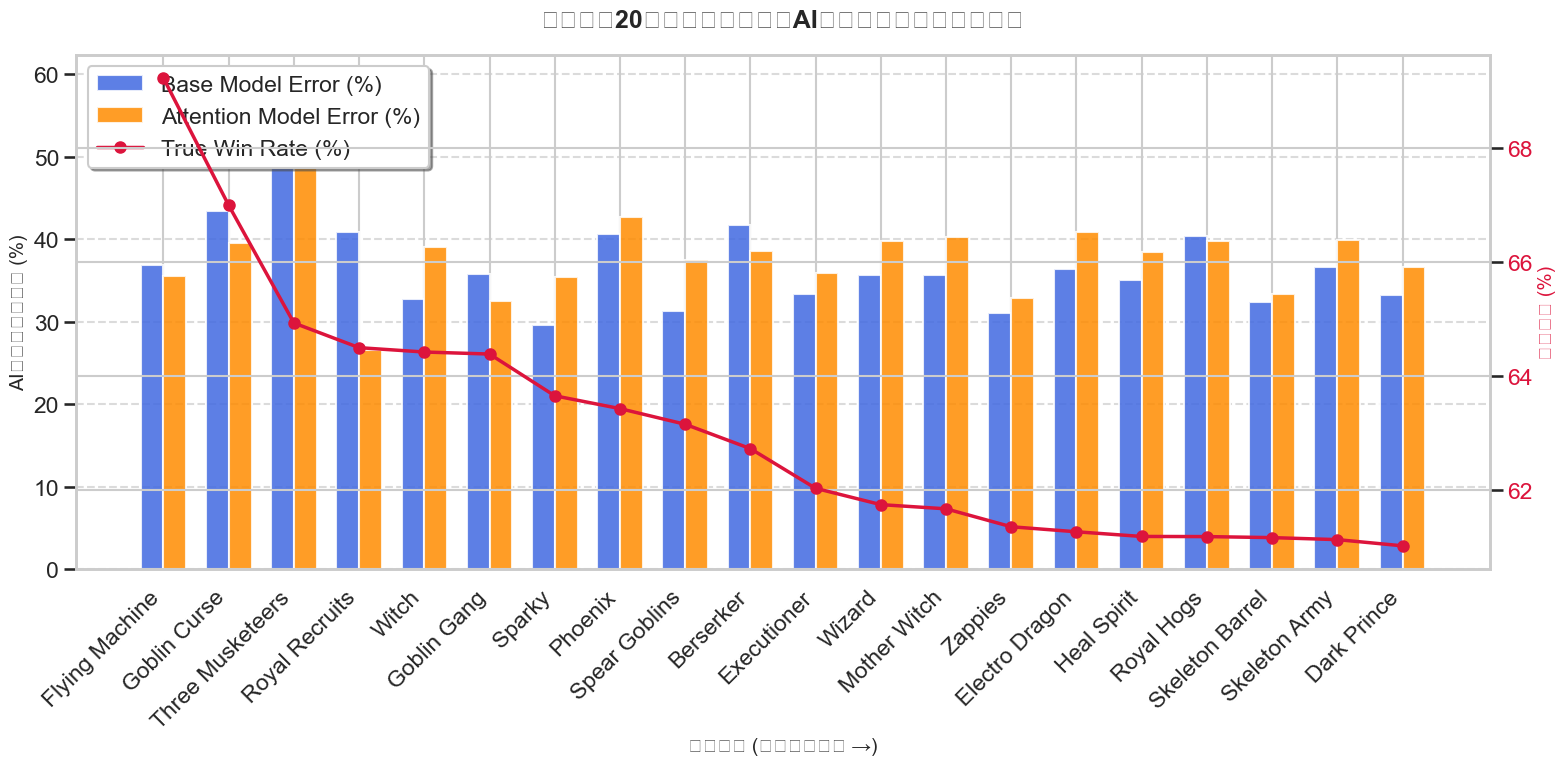

,card_name,win_rate,Base_Error_Rate,Attn_Error_Rate,Test_Match_Count
0,Flying Machine,69.2,36.8,35.5,76
1,Goblin Curse,67.0,43.4,39.5,76
2,Three Musketeers,64.9,59.4,59.4,32
3,Royal Recruits,64.5,40.8,26.5,98
4,Witch,64.4,32.7,39.1,156
5,Goblin Gang,64.4,35.8,32.5,120
6,Sparky,63.7,29.6,35.4,226
7,Phoenix,63.4,40.7,42.7,150
8,Spear Goblins,63.2,31.2,37.5,32
9,Berserker,62.7,41.7,38.5,96


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. 勝率Top20のカードが含まれる試合の「エラー率」を計算 ---
error_stats = []

for card in top_20_cards['card_name']:
    # そのカードが含まれている試合を抽出 (自分 or 相手のデッキ)
    matches_with_card = df_compare[
        df_compare['Deck_A_Base'].apply(lambda x: card in x) |
        df_compare['Deck_B_Base'].apply(lambda x: card in x)
    ]
    
    total_matches = len(matches_with_card)
    if total_matches == 0:
        continue
        
    # エラーになった回数を計算
    err_base = (~matches_with_card['Correct_Base']).sum()
    err_attn = (~matches_with_card['Correct_Attn']).sum()
    
    error_stats.append({
        'card_name': card,
        'Test_Match_Count': total_matches,
        'Base_Error_Rate': (err_base / total_matches) * 100,
        'Attn_Error_Rate': (err_attn / total_matches) * 100
    })

df_errors = pd.DataFrame(error_stats)

# --- 2. 勝率データ(top_20_cards)と結合 ---
df_plot = pd.merge(top_20_cards, df_errors, on='card_name')

# --- 3. 可視化（棒グラフ：エラー率、折れ線：勝率） ---
sns.set_theme(style="whitegrid", context="talk")
fig, ax1 = plt.subplots(figsize=(16, 8))

# X軸の設定
x = np.arange(len(df_plot))
width = 0.35

# ① 棒グラフ（モデルごとの予測エラー率）を描画
bars1 = ax1.bar(x - width/2, df_plot['Base_Error_Rate'], width, label='Base Model Error (%)', color='royalblue', alpha=0.85)
bars2 = ax1.bar(x + width/2, df_plot['Attn_Error_Rate'], width, label='Attention Model Error (%)', color='darkorange', alpha=0.85)

ax1.set_xlabel('カード名 (勝率が高い順 →)', fontsize=14)
ax1.set_ylabel('AIの予測エラー率 (%)', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot['card_name'], rotation=45, ha='right')
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

# ② 折れ線グラフ（カードの真の勝率）を重ねて描画
ax2 = ax1.twinx()
line = ax2.plot(x, df_plot['win_rate'], color='crimson', marker='o', markersize=8, linewidth=2.5, label='True Win Rate (%)')

ax2.set_ylabel('真の勝率 (%)', fontsize=14, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# 凡例を1つにまとめる
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

plt.title('勝率上位20カードにおける「AIの予測間違い率」の比較', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 念のためデータフレームの数値も表示
display(df_plot[['card_name', 'win_rate', 'Base_Error_Rate', 'Attn_Error_Rate', 'Test_Match_Count']].round(1))